In [4]:
#Importamos las librerias pandas, numpy y matplotlib respectivamente
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [7]:
#Carga desde un archivo .csv sin indice
data=pd.read_csv('Citas_Digital_Limpieza_Nulos.csv') 
data

,BDC,Fecha,Nombre Cliente,Telefono,Estatus de Lead,Potencial de compra,PDM,SDC,Venta,Asesor Asignado,¿Por que no ha visitado la agencia?,¿Por que no hay solicitud de credito?,¿Por que no hubo prueba de manejo ?,¿Por que no hubo proceso wow?,¿Por que se asigno antes de vistar piso?,Unnamed: 15
0,Saul,Sin dato,Guillermo,Sin dato,Finalizado,0.90,1.0,0.0,0.0,Nancy,"Ya visito la Agencia el dia jueves 17, intere...","Pide arrendamiento, unicamente se esta en espe...","Si, hizo prueba de manejo","Si recibio procesos wow, estuvo en la agencia ...","No, se espero a que visitara la agencia para s...",Comenta que no se le hizo atractivo el arrenda...
1,Saul,Sin dato,Roberto,Sin dato,Finalizado,0.40,0.0,0.0,0.0,Victor,Ya visito la Agencia el dia 3 de abril,Por que primero queria manejar las unidad,No habia unidad GS8 HEV para prueba de manejo,"Si recibio procesos wow, sin embargo no quizo ...",Se asigno hasta que visitara Piso,Sin respuesta
2,Saul,Sin dato,Irving,Sin dato,Finalizado,0.85,0.0,0.0,0.0,Alan,Ya visito la agencia el dia 21 de abril,"Firmo solicitud, sin embargo despues comento q...",Por que no habia unidad para prueba de manejo,"Si se realizo el proceso wow, los clientes se ...",Se asigno hasta que visitara Piso,Se le manda msj de seguimiento 03/05/2025
3,Saul,Sin dato,Oswaldo,Sin dato,Venta,0.90,0.0,0.0,1.0,Mauricio,El cliente vive en Tabasco Villahermosa,Sera compra de contado,"Ya la manejo en Villahermosa, sin embargo por ...","Las veces que se le ha marcado, agradece mucho...","Necesitabamos sacar el apartado, por eso se as...",Sin respuesta
4,Saul,Sin dato,Rodrigo,Sin dato,Finalizado,0.90,1.0,0.0,0.0,Mauricio,"Visito la agencia el mes pasado, y nos visita ...",Hoy visita nuevamente la agencia y se firma so...,"La primera vez que nos visito, realizo PDM",Si recibio el proceso wow la primera vez que n...,Se asigno hasta que visitara Piso la primera ...,Por el detalle del carbilink compro en otra ma...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
671,Ana,2026-07-22,Maira Escalante,Sin dato,Activo,0.80,1.0,1.0,0.0,Pedro Antonio,Sin respuesta,Sin respuesta,Sin respuesta,Sin respuesta,Sin respuesta,Sin respuesta
672,Ignacio,2026-07-22,Zaira Macip,Sin dato,Activo,0.50,0.0,0.0,0.0,Aurelio,Sin respuesta,Sin respuesta,Sin respuesta,Sin respuesta,Sin respuesta,Sin respuesta
673,Ignacio,2026-07-27,Julio Hernandez,Sin dato,Activo,0.50,1.0,0.0,0.0,Victor,Sin respuesta,Sin respuesta,Sin respuesta,Sin respuesta,Sin respuesta,Sin respuesta
674,Ignacio,2026-07-24,Xhunaxhi Vicente,Sin dato,Activo,1.00,1.0,1.0,1.0,Ignacio,Sin respuesta,Sin respuesta,Sin respuesta,Sin respuesta,Sin respuesta,Sin respuesta


In [13]:
#Verificar info del DataFrame
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 676 entries, 0 to 675
Data columns (total 16 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   BDC                                       676 non-null    str    
 1   Fecha                                     676 non-null    str    
 2   Nombre Cliente                            676 non-null    str    
 3   Telefono                                  676 non-null    str    
 4   Estatus de Lead                           676 non-null    str    
 5   Potencial de compra                       676 non-null    float64
 6   PDM                                       676 non-null    float64
 7   SDC                                       676 non-null    float64
 8   Venta                                     676 non-null    float64
 9   Asesor Asignado                           676 non-null    str    
 10  ¿Por que no ha visitado la agencia?       676 non

In [8]:
data.describe()

,Potencial de compra,PDM,SDC,Venta
count,676.000000,676.000000,676.000000,676.000000
mean,1.098447,0.501479,0.397929,0.085799
std,5.280653,0.597524,0.489833,0.280274
min,0.000000,0.000000,0.000000,0.000000
25%,0.700000,0.000000,0.000000,0.000000
50%,0.800000,0.000000,0.000000,0.000000
75%,0.800000,1.000000,1.000000,0.000000
max,80.000000,9.000000,1.000000,1.000000


In [31]:
#Solo trato Potencial de compra y PDM porque presentan valores fuera de su escala
cuantitativas = data.iloc[:,5:7]

#No trato SDC porque no tiene outliers, ni Venta porque sus valores 0 y 1 son válidos
cualitativas = data.iloc[:,[0,1,2,3,4,7,8,9,10,11,12,13,14,15]]

<Figure size 1500x800 with 0 Axes>

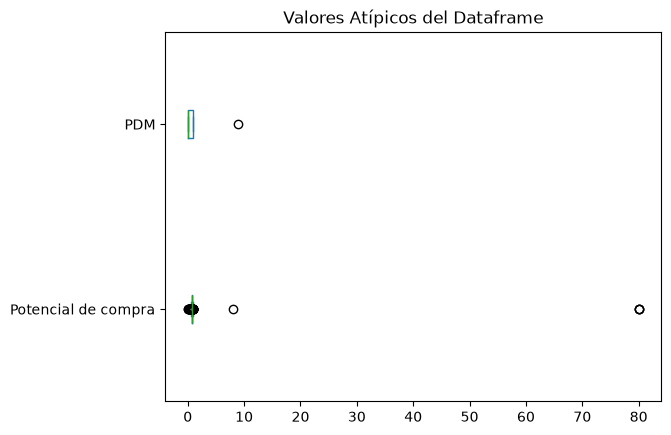

In [32]:
#Realizo un diagrama de caja para visualizar los posibles valores atípicos
fig = plt.figure(figsize=(15,8))
cuantitativas.plot(kind='box', vert=False)
plt.title("Valores Atípicos del Dataframe")
plt.show()

In [33]:
#Calculo los límites con 3 desviaciones estándar para detectar valores extremos
y=cuantitativas

Limite_Superior=y.mean()+3*y.std()
Limite_Inferior=y.mean()-3*y.std()

print("Limite Superior permitido",Limite_Superior)
print("Limite inferior permitido",Limite_Inferior)

Limite Superior permitido Potencial de compra    16.940406
PDM                     2.294051
dtype: float64
Limite inferior permitido Potencial de compra   -14.743513
PDM                    -1.291092
dtype: float64


In [34]:
#Los valores fuera de los límites se convierten en nulos para poder tratarlos
data3=cuantitativas[(y<=Limite_Superior)&(y>=Limite_Inferior)]
data3

,Potencial de compra,PDM
0,0.90,1.0
1,0.40,0.0
2,0.85,0.0
3,0.90,0.0
4,0.90,1.0
...,...,...
671,0.80,1.0
672,0.50,0.0
673,0.50,1.0
674,1.00,1.0


In [35]:
#Cuento los valores atípicos detectados en cada variable
valores_nulos=data3.isnull().sum()
valores_nulos

Potencial de compra    3
PDM                    1
dtype: int64

In [37]:
#Reviso los valores detectados como atípicos antes de sustituirlos
data[~data.index.isin(data3["Potencial de compra"].dropna().index)][["Potencial de compra"]]

,Potencial de compra
114,80.0
493,80.0
670,80.0


In [38]:
#Corrijo los valores 80 porque están fuera del rango que presentan los demás datos
data.loc[data["Potencial de compra"]==80, "Potencial de compra"] = 0.8

In [39]:
#Actualizo las variables después de corregir los valores inconsistentes
cuantitativas = data.iloc[:,5:7]
cuantitativas

,Potencial de compra,PDM
0,0.90,1.0
1,0.40,0.0
2,0.85,0.0
3,0.90,0.0
4,0.90,1.0
...,...,...
671,0.80,1.0
672,0.50,0.0
673,0.50,1.0
674,1.00,1.0


<Figure size 1500x800 with 0 Axes>

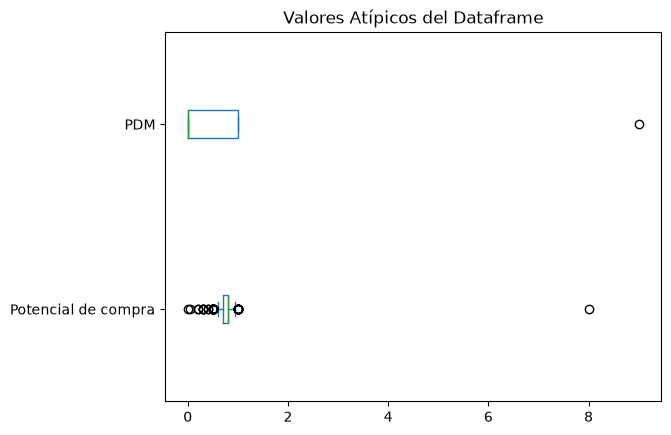

In [40]:
#Realizo nuevamente el diagrama de caja para revisar los valores atípicos
fig = plt.figure(figsize=(15,8))
cuantitativas.plot(kind='box', vert=False)
plt.title("Valores Atípicos del Dataframe")
plt.show()

In [41]:
#Reviso los valores fuera de la escala antes de aplicar los métodos
data[data["Potencial de compra"] > 1][["Potencial de compra"]]

,Potencial de compra
366,8.0


In [42]:
#Reviso los valores fuera de la escala de PDM
data[data["PDM"] > 1][["PDM"]]

,PDM
32,9.0


In [43]:
#Convierto los valores fuera de la escala en nulos porque no conozco su valor correcto
data.loc[data["Potencial de compra"] > 1, "Potencial de compra"] = np.nan
data.loc[data["PDM"] > 1, "PDM"] = np.nan

In [44]:
#Convierto los valores fuera de la escala en nulos porque no conozco su valor correcto
data.loc[data["Potencial de compra"] > 1, "Potencial de compra"] = np.nan
data.loc[data["PDM"] > 1, "PDM"] = np.nan

In [45]:
#Compruebo los valores nulos generados
data[["Potencial de compra","PDM"]].isnull().sum()

Potencial de compra    1
PDM                    1
dtype: int64

In [46]:
#Sustituyo el valor nulo de Potencial de compra con la mediana
data["Potencial de compra"] = data["Potencial de compra"].fillna(data["Potencial de compra"].median())

In [47]:
#Sustituyo el valor nulo de PDM con el valor más frecuente
data["PDM"] = data["PDM"].fillna(data["PDM"].mode()[0])

In [48]:
#Compruebo que ya no queden valores nulos
data[["Potencial de compra","PDM"]].isnull().sum()

Potencial de compra    0
PDM                    0
dtype: int64

In [49]:
#Actualizo las variables después de tratar los valores fuera de escala
cuantitativas = data.iloc[:,5:7]
cuantitativas

,Potencial de compra,PDM
0,0.90,1.0
1,0.40,0.0
2,0.85,0.0
3,0.90,0.0
4,0.90,1.0
...,...,...
671,0.80,1.0
672,0.50,0.0
673,0.50,1.0
674,1.00,1.0


<Figure size 1500x800 with 0 Axes>

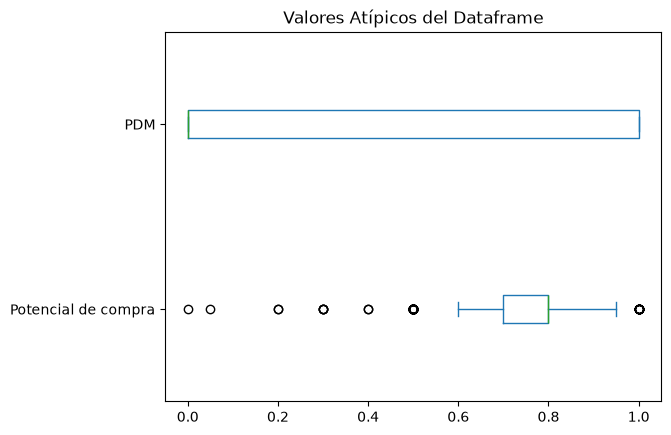

In [50]:
#Reviso nuevamente los valores atípicos
fig = plt.figure(figsize=(15,8))
cuantitativas.plot(kind='box', vert=False)
plt.title("Valores Atípicos del Dataframe")
plt.show()

In [ ]:
#Después de corregir los valores fuera de escala, PDM ya no presenta valores atípicos.
#En Potencial de compra aún se observan algunos puntos atípicos, principalmente en valores bajos.
#Sin embargo, estos se mantienen entre 0 y 1, por lo que pueden ser datos válidos y no necesariamente errores.

In [51]:
#Calculo los límites con desviación estándar para identificar posibles valores extremos
y = cuantitativas

Limite_Superior = y.mean() + 3*y.std()
Limite_Inferior = y.mean() - 3*y.std()

print("Limite Superior permitido", Limite_Superior)
print("Limite inferior permitido", Limite_Inferior)

Limite Superior permitido Potencial de compra    1.106648
PDM                    1.988856
dtype: float64
Limite inferior permitido Potencial de compra    0.365985
PDM                   -1.012524
dtype: float64


In [52]:
#Los valores fuera de los límites se convierten en nulos para identificar los posibles outliers
data3 = cuantitativas[(y<=Limite_Superior)&(y>=Limite_Inferior)]
data3

,Potencial de compra,PDM
0,0.90,1.0
1,0.40,0.0
2,0.85,0.0
3,0.90,0.0
4,0.90,1.0
...,...,...
671,0.80,1.0
672,0.50,0.0
673,0.50,1.0
674,1.00,1.0


In [53]:
#Reviso cuántos posibles outliers fueron detectados en cada variable
valores_nulos = data3.isnull().sum()
valores_nulos

Potencial de compra    8
PDM                    0
dtype: int64

In [54]:
#Reviso los valores detectados como outliers antes de decidir si deben ser sustituidos
data.loc[data3["Potencial de compra"].isnull(), ["Potencial de compra"]]

,Potencial de compra
6,0.20
20,0.20
32,0.00
72,0.05
502,0.30
503,0.30
531,0.30
532,0.30


In [ ]:
#Los 8 valores detectados los conservo porque están dentro de la escala válida de 0 a 1
#Aunque son poco frecuentes, no representan errores en la información

In [55]:
#Calculo los límites por cuartiles para identificar posibles valores atípicos
y = cuantitativas

percentile25 = y.quantile(0.25) #Q1
percentile75 = y.quantile(0.75) #Q3
iqr = percentile75 - percentile25

Limite_Superior_iqr = percentile75 + 1.5*iqr
Limite_Inferior_iqr = percentile25 - 1.5*iqr

print("Limite superior permitido", Limite_Superior_iqr)
print("Limite inferior permitido", Limite_Inferior_iqr)

Limite superior permitido Potencial de compra    0.95
PDM                    2.50
dtype: float64
Limite inferior permitido Potencial de compra    0.55
PDM                   -1.50
dtype: float64


In [56]:
#Los valores fuera de los límites se convierten en nulos para identificar los posibles outliers
data3_iqr = cuantitativas[(y<=Limite_Superior_iqr)&(y>=Limite_Inferior_iqr)]
data3_iqr

,Potencial de compra,PDM
0,0.90,1.0
1,NaN,0.0
2,0.85,0.0
3,0.90,0.0
4,0.90,1.0
...,...,...
671,0.80,1.0
672,NaN,0.0
673,NaN,1.0
674,NaN,1.0


In [57]:
#Reviso cuántos posibles outliers fueron detectados con el método de cuartiles
valores_nulos = data3_iqr.isnull().sum()
valores_nulos

Potencial de compra    72
PDM                     0
dtype: int64

In [58]:
#Reviso los valores detectados como outliers por cuartiles antes de decidir si deben ser sustituidos
data.loc[data3_iqr["Potencial de compra"].isnull(), "Potencial de compra"].value_counts().sort_index()

Potencial de compra
0.00     1
0.05     1
0.20     2
0.30     4
0.40     2
0.50    45
1.00    17
Name: count, dtype: int64

In [59]:
#Los 72 valores detectados por cuartiles están dentro de la escala válida de la variable
#Por esta razón los conservo, ya que son valores atípicos estadísticamente pero no datos incorrectos

In [60]:
#Compruebo que el DataFrame final no tenga valores nulos
valores_nulos = data.isnull().sum()
valores_nulos

BDC                                         0
Fecha                                       0
Nombre Cliente                              0
Telefono                                    0
Estatus de Lead                             0
Potencial de compra                         0
PDM                                         0
SDC                                         0
Venta                                       0
Asesor Asignado                             0
¿Por que no ha visitado la agencia?         0
¿Por que no hay solicitud de credito?       0
¿Por que no hubo prueba de manejo ?         0
¿Por que no hubo proceso wow?               0
¿Por que se asigno antes de vistar piso?    0
Unnamed: 15                                 0
dtype: int64

In [61]:
#Compruebo el total de valores nulos
data.isnull().sum().sum()

np.int64(0)

In [62]:
#Reviso los valores finales de las variables numéricas
data[["Potencial de compra","PDM","SDC","Venta"]].describe()

,Potencial de compra,PDM,SDC,Venta
count,676.000000,676.000000,676.000000,676.000000
mean,0.736317,0.488166,0.397929,0.085799
std,0.123444,0.500230,0.489833,0.280274
min,0.000000,0.000000,0.000000,0.000000
25%,0.700000,0.000000,0.000000,0.000000
50%,0.800000,0.000000,0.000000,0.000000
75%,0.800000,1.000000,1.000000,0.000000
max,1.000000,1.000000,1.000000,1.000000


In [63]:
#Guardo el DataFrame después de la limpieza de valores atípicos
data.to_csv("Citas_Digital_Limpieza_Outliers.csv", index=False)